# Basic Diffusion Kernel Breakdown and Analysis.

## Preamble

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import scipy.linalg
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics import adjusted_rand_score

from clustering.spectral import dist_mat, knn_affinity
from clustering.alc import ALCAdapter
from data.generators import make_blobs_convex, make_two_moons, make_rings

import matplotlib.gridspec as gridspec
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

from scipy.linalg import expm

### Plotting Matrices Function

In [2]:
def plot_matrix(
    matrix: np.ndarray,
    title: str,
    matrix_type: str = "affinity",
    ax: plt.Axes = None,
    reorder: bool = True
) -> plt.Axes:
    """
    Plot a single matrix as a heatmap.

    Parameters
    ----------
    matrix      : Square numpy array to visualise
    title       : Plot title
    matrix_type : One of 'affinity', 'distance', 'correlation', 'laplacian'
    ax          : Existing matplotlib Axes (creates new figure if None)
    reorder     : Whether to reorder rows/columns via hierarchical clustering
    """
    CMAPS = {
        "affinity":    "viridis",
        "distance":    "plasma",
        "correlation": "RdBu_r",
        "laplacian":   "RdBu_r",
    }
    VLIMS = {
        "affinity":    (0, None),
        "distance":    (0, None),
        "correlation": (-1, 1),
        "laplacian":   (None, None),  # symmetric around 0 but range varies
    }

    cmap = CMAPS.get(matrix_type, "viridis")
    vmin, vmax = VLIMS.get(matrix_type, (None, None))

    # For laplacian, centre the colourmap symmetrically around zero
    if matrix_type == "laplacian":
        abs_max = np.abs(matrix).max()
        vmin, vmax = -abs_max, abs_max

    if reorder:
        if matrix_type == "distance":
            condensed = squareform(matrix)
        elif matrix_type == "laplacian":
            # Convert to an affinity-like measure for clustering purposes
            condensed = squareform(np.abs(matrix) / (np.abs(matrix).max() + 1e-10))
        else:
            condensed = squareform(1 - matrix / (matrix.max() + 1e-10))

        linkage_matrix = linkage(condensed, method="ward")
        order = dendrogram(linkage_matrix, no_plot=True)["leaves"]
        matrix = matrix[np.ix_(order, order)]

    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))

    im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=11, pad=8)
    ax.set_xlabel("Node index", fontsize=9)
    ax.set_ylabel("Node index", fontsize=9)
    ax.tick_params(labelsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    return ax


def plot_matrix_comparison(
    matrices: dict,
    matrix_type: str = "affinity",
    reorder: bool = True,
    figsize: tuple = None,
    suptitle: str = None
) -> plt.Figure:
    """
    Plot multiple matrices side by side for comparison.

    Parameters
    ----------
    matrices    : Dict of {title: np.ndarray}
    matrix_type : One of 'affinity', 'distance', 'correlation', 'laplacian'
    reorder     : Whether to reorder via hierarchical clustering
    figsize     : Figure size override
    suptitle    : Overall figure title

    Returns
    -------
    fig : matplotlib Figure
    """
    n = len(matrices)
    if figsize is None:
        figsize = (5 * n, 4.5)

    fig = plt.figure(figsize=figsize)
    gs  = gridspec.GridSpec(1, n, figure=fig, wspace=0.35)

    for idx, (title, matrix) in enumerate(matrices.items()):
        ax = fig.add_subplot(gs[0, idx])
        plot_matrix(
            matrix=matrix,
            title=title,
            matrix_type=matrix_type,
            ax=ax,
            reorder=reorder
        )

    if suptitle:
        fig.suptitle(suptitle, fontsize=13, y=1.02, fontweight="medium")

    plt.tight_layout()
    return fig

## Data Generation

### Blobs

In [ ]:
blobs, blobs_labels = make_blobs_convex(N=500, num_clusters=7, n_features=5000)
blobs.shape

In [ ]:
plt.scatter(x=blobs[:,1], y=blobs[:,2], c=blobs_labels)

### Concentric Cirles

In [3]:
rings, rings_labels = make_rings(n_points=500, n_circles=3, noise_std=0.15)

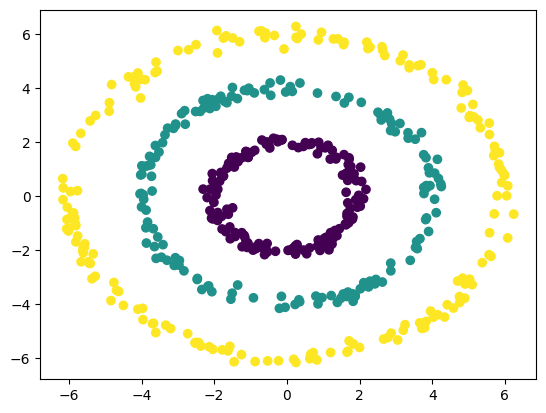

In [4]:
plt.scatter(x=rings[:,0], y=rings[:,1], c=rings_labels)

### Two Moons

In [32]:
moons, moons_labels = make_two_moons(n_samples=500, noise=0.05)

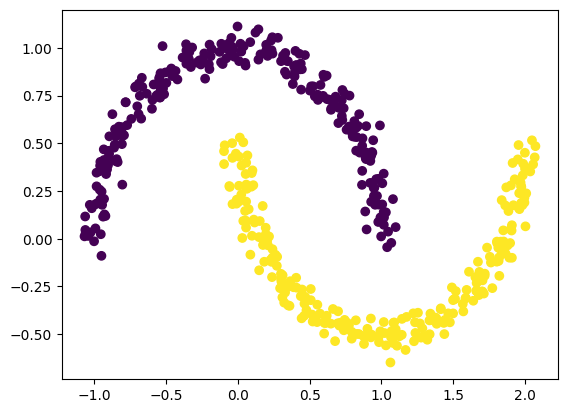

In [33]:
plt.scatter(x=moons[:,0], y=moons[:,1], c=moons_labels)

## Graph Construction

### Distance Matrix


In [5]:
# ---------------- Distance matrix ----------------
def dist_mat(X):
    """Compute pairwise Euclidean distances (N x N)."""
    return cdist(X, X, "euclidean")

### Affinity Matrix

In [6]:
def knn_affinity(dist_matrix, k, sigma):
    """
    Build a symmetric k-NN Gaussian affinity matrix from a precomputed
    pairwise distance matrix.

    Parameters
    ----------
    dist_matrix : (n, n) ndarray  — pairwise Euclidean distances, zero diagonal.
    k           : int             — number of nearest neighbours per point.
    sigma       : float           — Gaussian kernel bandwidth.

    Returns
    -------
    A : (n, n) ndarray  — symmetric, non-negative, zero diagonal.
    """
    n = dist_matrix.shape[0]

    # Fully connected fallback (backward-compatible)
    if k >= n - 1:
        A = np.exp(-dist_matrix ** 2 / (2.0 * sigma ** 2))
        np.fill_diagonal(A, 0.0)
        return A

    # Step 1 — k nearest neighbours per row (skip self at index 0)
    sorted_idx = np.argsort(dist_matrix, axis=1)
    nn_idx     = sorted_idx[:, 1:k + 1]          # (n, k)

    # Step 2 — directed adjacency mask
    nn_mask      = np.zeros((n, n), dtype=bool)
    rows         = np.repeat(np.arange(n), k)
    nn_mask[rows, nn_idx.ravel()] = True

    # Step 3 — OR-symmetrisation
    sym_mask = nn_mask | nn_mask.T

    # Step 4-5 — Gaussian weights applied to retained edges only
    W = np.exp(-dist_matrix ** 2 / (2.0 * sigma ** 2))
    A = W * sym_mask
    np.fill_diagonal(A, 0.0)
    return A


In [53]:
# Distance Matrices
rings_dist_mat = dist_mat(moons)

<Axes: title={'center': 'Rings Distance Matrix'}, xlabel='Node index', ylabel='Node index'>

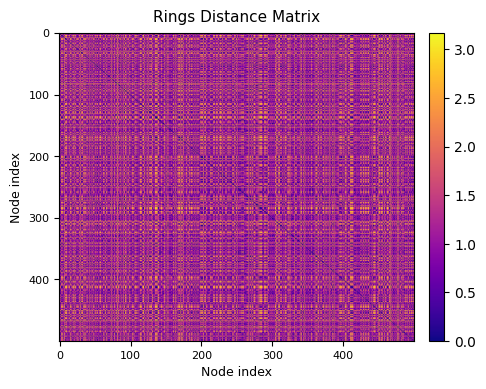

In [54]:
# Visualise Distance Matrix
plot_matrix(matrix=rings_dist_mat, title="Rings Distance Matrix", matrix_type="distance", ax=None, reorder=False)

In [63]:
# Generating the affinity matrix 
# Arbitrarily selecting k and sigma for now, just picked based on what made the visualisation look best,
#  i.e. clearest distinction between diagonals and off-diagonals 
rings_affinity = knn_affinity(rings_dist_mat, k=20, sigma=0.25)

<Axes: title={'center': 'Rings Affinity Matrix'}, xlabel='Node index', ylabel='Node index'>

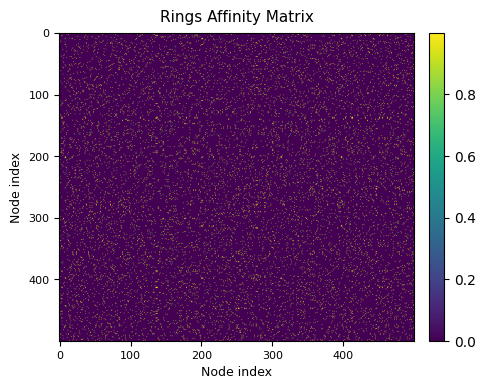

In [64]:
# Visualise Affinity Matrix
plot_matrix(matrix=rings_affinity, title="Rings Affinity Matrix", matrix_type="affinity", ax=None, reorder=False)

### Diffusion Kernel

We will look at only the unnormalised and symmetric graph Laplacians, since they meet the definition of a kernel (symmetric and PSD).

In [65]:
def diffusion_kernel(affinity, t):
    diff_K = expm(-t * affinity) # matrix exponential *not* elementwise operator
    return(diff_K)

In [72]:
rings_diff = diffusion_kernel(rings_affinity, t=15)

<Axes: title={'center': 'Rings Kernel Matrix'}, xlabel='Node index', ylabel='Node index'>

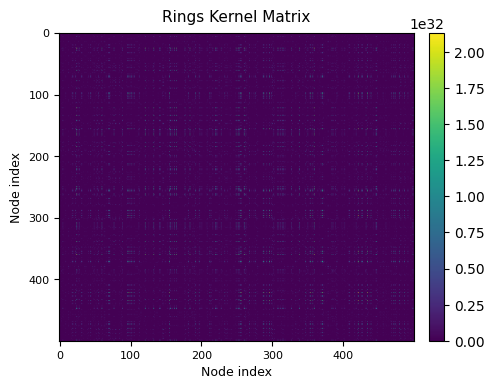

In [73]:
# Visualise Kernel Matrix
plot_matrix(matrix=rings_diff, title="Rings Kernel Matrix", matrix_type="affinity", ax=None, reorder=False)

### Intra-cluster and Inter-cluster Distribution


In [26]:
def affinity_distributions(W, labels):
    """
    Compute intra- and inter-cluster affinity distributions.

    Parameters
    ----------
    W      : (N, N) ndarray — affinity or kernel matrix
    labels : (N,) ndarray  — ground truth cluster labels

    Returns
    -------
    intra : 1D array of intra-cluster affinities (within the cluster)
    inter : 1D array of inter-cluster affinities (in-between the cluster)
    """
    N = W.shape[0]
    intra, inter = [], []

    for i in range(N):
        for j in range(i + 1, N):
            if labels[i] == labels[j]:
                intra.append(W[i, j])
            else:
                inter.append(W[i, j])

    return np.array(intra), np.array(inter)

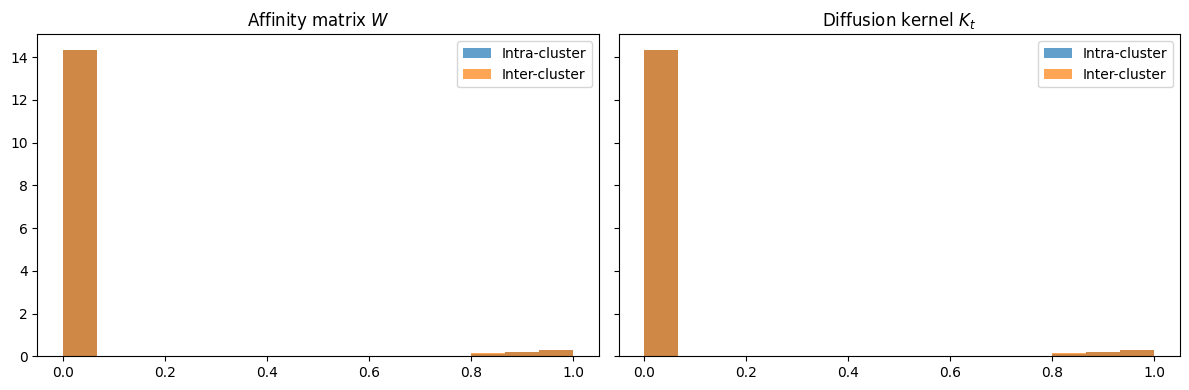

In [74]:
intra_W, inter_W = affinity_distributions(rings_affinity, rings_labels)
intra_K, inter_K = affinity_distributions(rings_affinity, rings_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(intra_W, bins=15, alpha=0.7, label="Intra-cluster", range=(0,1), density=True)
axes[0].hist(inter_W, bins=15, alpha=0.7, label="Inter-cluster", range=(0,1), density=True)
axes[0].set_title("Affinity matrix $W$")
axes[0].legend()

axes[1].hist(intra_K, bins=15, alpha=0.7, label="Intra-cluster", range=(0,1), density=True)
axes[1].hist(inter_K, bins=15, alpha=0.7, label="Inter-cluster", range=(0,1), density=True)
axes[1].set_title(r"Diffusion kernel $K_t$")
axes[1].legend()

plt.tight_layout()

In [77]:
sum(intra_W - intra_K)

np.float64(0.0)

### Laplacian 

In [51]:
def build_laplacian(A, laplacian_type):
    """
    Build a graph Laplacian from affinity matrix A.

    Parameters
    ----------
    A : (n, n) ndarray
        Symmetric non-negative affinity matrix.
    laplacian_type : {"unnorm", "sym", "rw"}
        Laplacian formulation to use.

    Returns
    -------
    L : (n, n) ndarray
    d : (n,) ndarray  — degree vector
    """
    n = A.shape[0]
    d = A.sum(axis=1)
    I = np.eye(n)

    if laplacian_type == "unnorm":
        D = np.diag(d)
        L = D - A

    elif laplacian_type == "sym":
        D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
        L = I - D_inv_sqrt @ A @ D_inv_sqrt

    elif laplacian_type == "rw":
        D_inv = np.diag(1.0 / d)
        L = I - D_inv @ A

    else:
        raise ValueError(f"Unknown laplacian_type '{laplacian_type}'. Use 'unnorm', 'sym', or 'rw'.")

    return L, d




In [52]:
rings_lap_raw = build_laplacian(rings_affinity, "unnorm")
rings_lap_sym = build_laplacian(rings_affinity, "sym")
rings_lap_rw  = build_laplacian(rings_affinity, "rw")


---
## Blobs Analysis

### Distance Matrix

In [ ]:
# Distance Matrices
blobs_dist_mat = dist_mat(blobs)

In [ ]:
# Visualise Distance Matrix
plot_matrix(matrix=blobs_dist_mat, title="Blobs Distance Matrix", matrix_type="distance", ax=None, reorder=False)

### Affinity Matrix

In [ ]:
# Generating the affinity matrix
# Blobs are 5000-dimensional so pairwise distances are much larger than for rings.
# sigma=25 chosen to give a similar visual separation to rings at sigma=0.25.
blobs_affinity = knn_affinity(blobs_dist_mat, k=200, sigma=25)

In [ ]:
# Visualise Affinity Matrix
plot_matrix(matrix=blobs_affinity, title="Blobs Affinity Matrix", matrix_type="affinity", ax=None, reorder=False)

### Laplacian

In [ ]:
blobs_lap_raw = build_laplacian(blobs_affinity, "unnorm")
blobs_lap_sym = build_laplacian(blobs_affinity, "sym")
blobs_lap_rw  = build_laplacian(blobs_affinity, "rw")

### Diffusion Kernel

In [ ]:
blobs_diff_unnorm = diffusion_kernel(blobs_lap_raw[0], t=1)

In [ ]:
blobs_diff_sym = diffusion_kernel(blobs_lap_sym[0], t=5)

In [ ]:
# Visualise Kernel Matrix
plot_matrix(matrix=blobs_diff_sym, title="Blobs Kernel Matrix", matrix_type="affinity", ax=None, reorder=False)

### Intra-cluster and Inter-cluster Distribution

In [ ]:
intra_W, inter_W = affinity_distributions(blobs_affinity, blobs_labels)
intra_K, inter_K = affinity_distributions(blobs_diff_sym, blobs_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(intra_W, bins=15, alpha=0.7, label="Intra-cluster", range=(0,0.05), density=True)
axes[0].hist(inter_W, bins=15, alpha=0.7, label="Inter-cluster", range=(0,0.05), density=True)
axes[0].set_title("Affinity matrix $W$")
axes[0].legend()

axes[1].hist(intra_K, bins=15, alpha=0.7, label="Intra-cluster", range=(0,0.05), density=True)
axes[1].hist(inter_K, bins=15, alpha=0.7, label="Inter-cluster", range=(0,0.05), density=True)
axes[1].set_title(r"Diffusion kernel $K_t$")
axes[1].legend()

plt.tight_layout()

**Notes:**
- The blobs data is 5000-dimensional so `blobs[:,1]` and `blobs[:,2]` in the scatter plot above show only two of 5000 features — the visual may not reflect true cluster separation. Consider reducing to 2D for visualisation.
- The scatter plot cell references `blobs_label` (missing the `s`); this will raise a `NameError` — the correct variable is `blobs_labels`.
- The histogram `range=(0, 0.005)` was tuned for rings. For 5000-dimensional blobs the affinity values may sit in a different range; adjust if the histograms appear empty.

---
## Moons Analysis

### Distance Matrix

In [ ]:
# Distance Matrices
moons_dist_mat = dist_mat(moons)

In [ ]:
# Visualise Distance Matrix
plot_matrix(matrix=moons_dist_mat, title="Moons Distance Matrix", matrix_type="distance", ax=None, reorder=False)

### Affinity Matrix

In [ ]:
# Generating the affinity matrix
# Moons are 2D with coordinates roughly in [-1, 2] x [-1, 1.5].
# sigma=0.25 matches rings (also 2D, similar coordinate scale).
moons_affinity = knn_affinity(moons_dist_mat, k=1000, sigma=0.25)

In [ ]:
# Visualise Affinity Matrix
plot_matrix(matrix=moons_affinity, title="Moons Affinity Matrix", matrix_type="affinity", ax=None, reorder=False)

### Laplacian

In [ ]:
moons_lap_raw = build_laplacian(moons_affinity, "unnorm")
moons_lap_sym = build_laplacian(moons_affinity, "sym")
moons_lap_rw  = build_laplacian(moons_affinity, "rw")

### Diffusion Kernel

In [ ]:
moons_diff_unnorm = diffusion_kernel(moons_lap_raw[0], t=1)

In [ ]:
moons_diff_sym = diffusion_kernel(moons_lap_sym[0], t=10)

In [ ]:
# Visualise Kernel Matrix
plot_matrix(matrix=moons_diff_unnorm, title="Moons Kernel Matrix", matrix_type="affinity", ax=None, reorder=False)

### Intra-cluster and Inter-cluster Distribution

In [ ]:
intra_W, inter_W = affinity_distributions(moons_affinity, moons_labels)
intra_K, inter_K = affinity_distributions(moons_diff_sym, moons_labels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

axes[0].hist(intra_W, bins=15, alpha=0.7, label="Intra-cluster", range=(0,1), density=True)
axes[0].hist(inter_W, bins=15, alpha=0.7, label="Inter-cluster", range=(0,1), density=True)
axes[0].set_title("Affinity matrix $W$")
axes[0].legend()

axes[1].hist(intra_K, bins=15, alpha=0.7, label="Intra-cluster", range=(0,1), density=True)
axes[1].hist(inter_K, bins=15, alpha=0.7, label="Inter-cluster", range=(0,1), density=True)
axes[1].set_title(r"Diffusion kernel $K_t$")
axes[1].legend()

plt.tight_layout()

In [ ]:
np.sort(intra_W)[::-1]


**Notes:**
- Moons are non-convex — the fully connected affinity (k=2000) will assign non-zero weight to cross-cluster pairs that happen to be geographically close (near the tips of the arcs). The intra/inter separation in W may therefore look poor. This is the motivating case for k-NN sparsification.
- At t=500000 the diffusion kernel is effectively at steady state (all information has diffused). For moons this means K_t entries will be nearly uniform across each connected component — check whether the intra/inter separation actually improves or collapses.
- The histogram `range=(0, 0.005)` may need widening for moons; the affinity values for a tighter geometry can be larger.